# ballester2024 — Predicting the Generalization Gap with TDA

**Ballester, Arnal Clemente, Casacuberta, Madadi, Corneanu & Escalera (2024).**
*Predicting the generalization gap in neural networks using topological data analysis.*
Neurocomputing **596**, 127787. — [paper](https://doi.org/10.1016/j.neucom.2024.127787) ·
[code](https://github.com/rballeba/PredictingGeneralizationGapUsingPersistentHomology)

The **generalization gap** of a trained network is `Acc_train − Acc_test`.  This paper
predicts it *from the training set alone* — no test labels needed — using the
topology of the network's own neuron activations.

## What the paper does

**1. Functional graph.**  Feed a trained network `N` a dataset `D`.  Each non-input
neuron `v` gets an *activation vector* `A_v(D) = (N_v(x))_{x∈D}`.  Build a complete
weighted graph on the neurons with the **correlation distance**

$$d(v_i, v_j) \;=\; 1 - \bigl|\,\mathrm{corr}\!\left(A_{v_i}(D),\, A_{v_j}(D)\right)\bigr|,$$

where `corr` is the Pearson coefficient.  Constant (zero-variance) neurons are dropped.

**2. Persistent homology.**  Take the Vietoris–Rips filtration of that
neuron×neuron distance matrix and read off persistence diagrams in dimensions
`H0` and `H1` (coefficients in `F2`).

**3. Persistence summaries.**  Vectorise each diagram.  Of the eleven summaries the
paper tries, the winner is **ASDSQ** — the **A**verage and **S**tandard **D**eviation
of births and deaths *and of their element-wise* **SQ**uares.  Per homology
dimension that is the 8-vector

```
[ mean(b), std(b), mean(d), std(d),  mean(b²), std(b²), mean(d²), std(d²) ]
```

and `ASDSQ01` stacks `H0` and `H1` into a single 16-vector.

**4. Regression.**  Fit a *linear* model from the ASDSQ vectors of many trained
networks onto their generalization gaps, scored by `R²` under 5×2-fold CV.

**5. Sampling (for scale).**  Real nets have thousands of neurons, so the paper
sub-samples 2000 inputs and importance-samples 3000 neurons (Eqs. 4.2–4.3),
repeats 20× and bootstraps the summaries.

### Headline results (paper)

| Task | Dataset | Networks | Best summary | `R²` |
|------|---------|----------|--------------|------|
| 1 | CIFAR-10 | 96 VGG-like | **ASDSQ**, `H0`&`H1` | 0.560 ± 0.13 |
| 2 | SVHN | 54 network-in-network | **ASD**, `H1` | 0.934 ± 0.01 |

**Interpretation (Fig. 4.3):** fixing depth, a *higher average of deaths* together
with a *lower standard deviation of deaths* goes with a *smaller* generalization gap.

## Where each step lives

Steps 1–3 are **built into the toolkit**, so this notebook never hand-rolls the
functional graph or the summary:

| Paper step | Toolkit home |
|---|---|
| correlation functional graph, drop constant neurons, importance-sample neurons (Eqs. 4.2–4.3) | `activation_graph` **builder** (`distance="correlation"`, `drop_constant`, `node_sampling="importance"`, `max_neurons`) |
| **ASDSQ** persistence summary | `topo_tools.compute_statistics(..., stat_names=["asdsq"])` → `result.statistics` |
| one summary **per model** over a population | `TDAPipeline.fit_each(models, data)` |

All three are pre-wired in `TDAPipeline.from_paper("ballester2024")`.  Only step 4 —
the linear regression of the gap onto ASDSQ — stays in the notebook, since fitting a
regressor is the downstream task, not a topological computation.

We train a small **population of VGG-like CNNs on CIFAR-10** on the laptop GPU
(Apple MPS / CUDA); at this reduced scale (≈16 nets, a few hundred neurons/inputs,
brief training) the `R²` is lower and noisier than the paper's full-scale run — the
*qualitative* relationship is what to look for.

## Setup

In [1]:
import sys, pathlib, warnings, time
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_cifar10, VGGLike, train_briefly, accuracy, pick_device,
)

warnings.filterwarnings("ignore")          # quiet the per-fit layer-selection notes
np.random.seed(0); torch.manual_seed(0)

DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'
print("training device:", DEVICE)

training device: mps


## 1. The paper preset — functional graph + ASDSQ, pre-wired

In [2]:
pipe = TDAPipeline.from_paper("ballester2024")
pipe.explain()

# The 16 ASDSQ feature keys the preset emits into result.statistics.
_STATS = ["mean_birth", "std_birth", "mean_death", "std_death",
          "mean_birth_sq", "std_birth_sq", "mean_death_sq", "std_death_sq"]
ASDSQ_KEYS = [f"H{d}_{s}" for d in (0, 1) for s in _STATS]
print("\nASDSQ feature keys:\n ", ASDSQ_KEYS)

TDAPipeline — Ballester et al. (2024)
  Stage 1: builder = activation_graph
             distance = 'correlation'
             drop_constant = True
             node_sampling = 'importance'
             max_neurons = 300
  Stage 2: tool    = ph
             max_dim = 1
             backend = 'ripser'
             stat_names = ['asdsq']
  Default plot   : .plot('diagram')

ASDSQ feature keys:
  ['H0_mean_birth', 'H0_std_birth', 'H0_mean_death', 'H0_std_death', 'H0_mean_birth_sq', 'H0_std_birth_sq', 'H0_mean_death_sq', 'H0_std_death_sq', 'H1_mean_birth', 'H1_std_birth', 'H1_mean_death', 'H1_std_death', 'H1_mean_birth_sq', 'H1_std_birth_sq', 'H1_mean_death_sq', 'H1_std_death_sq']


## 2. A population of VGG-like CNNs on CIFAR-10

The paper's Task 1 sweeps 96 VGG-like nets over depth, width, dropout and weight
decay.  We mirror that sweep at small scale: a 4×4 grid over **(capacity)** ×
**(regularization)** gives 16 nets whose generalization gaps span a useful range.
Raise `EPOCHS`, `N_TRAIN`, `N_EVAL`, `MAX_NEURONS` or the grid size toward
paper-scale numbers (GPU recommended).

In [3]:
# ── tunables ────────────────────────────────────────────────────────────────
N_TRAIN, N_TEST = 1500, 1000     # CIFAR-10 subset sizes
N_EVAL          = 256            # inputs used to build the functional graph
EPOCHS          = 30             # per-model training epochs
MAX_NEURONS     = 300            # neuron budget for the importance sampler
# ────────────────────────────────────────────────────────────────────────────

X_tr, y_tr = load_cifar10("train", n_samples=N_TRAIN)
X_te, y_te = load_cifar10("test",  n_samples=N_TEST)

CONFIGS = []
for n_blocks, cpb, width, hidden in [(2, 1, 16, 128), (2, 2, 24, 128),
                                     (3, 1, 32, 128), (3, 2, 32, 256)]:
    for dropout, wd in [(0.0, 0.0), (0.5, 0.0), (0.0, 1e-3), (0.5, 1e-3)]:
        CONFIGS.append(dict(n_blocks=n_blocks, convs_per_block=cpb, base_width=width,
                            hidden=hidden, dropout=dropout, weight_decay=wd,
                            depth=n_blocks * cpb))
print(f"{len(CONFIGS)} configurations to train")

16 configurations to train


### Train each net and record its true generalization gap

In [4]:
models, rows = [], []
t0 = time.time()
for i, cfg in enumerate(CONFIGS):
    arch = {k: cfg[k] for k in ("n_blocks", "convs_per_block", "base_width", "hidden", "dropout")}
    torch.manual_seed(i)
    model = VGGLike(**arch)
    train_briefly(model, X_tr, y_tr, X_te, y_te, epochs=EPOCHS,
                  weight_decay=cfg["weight_decay"], device=DEVICE, verbose=False)

    acc_tr = accuracy(model, X_tr, y_tr, device=DEVICE)
    acc_te = accuracy(model, X_te, y_te, device=DEVICE)
    models.append(model.to("cpu"))
    rows.append(dict(model=i, depth=cfg["depth"], dropout=cfg["dropout"],
                     wd=cfg["weight_decay"], acc_tr=acc_tr, acc_te=acc_te,
                     gap=acc_tr - acc_te))
    print(f"[{i:2d}] depth={cfg['depth']} drop={cfg['dropout']} wd={cfg['weight_decay']:.0e}"
          f"  train={acc_tr:.3f} test={acc_te:.3f} gap={acc_tr-acc_te:.3f}")

meta = pd.DataFrame(rows)
print(f"\ntrained {len(models)} nets in {time.time()-t0:.0f}s")

[ 0] depth=2 drop=0.0 wd=0e+00  train=0.409 test=0.342 gap=0.067


[ 1] depth=2 drop=0.5 wd=0e+00  train=0.442 test=0.387 gap=0.055


[ 2] depth=2 drop=0.0 wd=1e-03  train=0.349 test=0.324 gap=0.025


[ 3] depth=2 drop=0.5 wd=1e-03  train=0.447 test=0.397 gap=0.050


[ 4] depth=4 drop=0.0 wd=0e+00  train=0.607 test=0.409 gap=0.198


...

[11] depth=3 drop=0.5 wd=1e-03  train=0.510 test=0.350 gap=0.160


[12] depth=6 drop=0.0 wd=0e+00  train=0.993 test=0.519 gap=0.474


[13] depth=6 drop=0.5 wd=0e+00  train=0.677 test=0.422 gap=0.255


[14] depth=6 drop=0.0 wd=1e-03  train=0.751 test=0.392 gap=0.359


[15] depth=6 drop=0.5 wd=1e-03  train=0.781 test=0.420 gap=0.361

trained 16 nets in 82s


## 3. One call: ASDSQ for every model

`fit_each` runs the whole preset — extract activations → concatenate the network's
neurons → drop constant neurons → importance-sample to `MAX_NEURONS` → correlation
VR persistent homology → **ASDSQ** — independently for each model, and returns one
`TopoResult` per net with the summary already in `.statistics`.

In [5]:
# Set the neuron budget on the preset, then fit every model in one call.
pipe = TDAPipeline.from_paper("ballester2024", builder_kwargs__max_neurons=MAX_NEURONS)
results = pipe.fit_each(models, X_te[:N_EVAL],
                        representation="activations",       # concat whole-network units
                        layer_selection="linear_and_conv")  # conv channels + dense neurons

S = np.array([[r.statistics[k] for k in ASDSQ_KEYS] for r in results])   # (n_models, 16)
print("ASDSQ matrix:", S.shape,
      "| functional-graph size:", results[0].ph_result.diagrams[0].shape[0], "neurons")

ASDSQ matrix: (16, 16) | functional-graph size: 300 neurons


### The ASDSQ summary for every model

In [6]:
asdsq_df = pd.DataFrame(S, columns=ASDSQ_KEYS)
table = pd.concat([meta[["model", "depth", "dropout", "wd", "gap"]], asdsq_df], axis=1)
# H0 births are ~0 by construction (VR H0 bars are born at filtration 0), so those
# columns are all-zero and carry no information — show the informative ones.
informative = [c for c in ASDSQ_KEYS if not np.allclose(S[:, ASDSQ_KEYS.index(c)], 0)]
table[["model", "depth", "dropout", "wd", "gap"] + informative].round(3)

,model,depth,dropout,wd,gap,H0_mean_death,H0_std_death,H0_mean_death_sq,H0_std_death_sq,H1_mean_birth,H1_std_birth,H1_mean_death,H1_std_death,H1_mean_birth_sq,H1_std_birth_sq,H1_mean_death_sq,H1_std_death_sq
0,0,2,0.0,0.000,0.067,0.445,0.179,0.230,0.159,0.691,0.122,0.729,0.116,0.492,0.156,0.545,0.153
1,1,2,0.5,0.000,0.055,0.403,0.161,0.189,0.130,0.652,0.114,0.699,0.105,0.438,0.146,0.500,0.139
2,2,2,0.0,0.001,0.025,0.459,0.170,0.240,0.149,0.681,0.123,0.719,0.116,0.479,0.154,0.531,0.150
3,3,2,0.5,0.001,0.050,0.432,0.159,0.212,0.139,0.645,0.118,0.694,0.104,0.429,0.147,0.493,0.138
4,4,4,0.0,0.000,0.198,0.554,0.139,0.327,0.136,0.742,0.086,0.777,0.077,0.558,0.119,0.609,0.111
5,5,4,0.5,0.000,0.213,0.493,0.179,0.276,0.156,0.738,0.086,0.774,0.079,0.552,0.116,0.606,0.110
6,6,4,0.0,0.001,0.171,0.539,0.157,0.315,0.151,0.751,0.076,0.787,0.066,0.569,0.106,0.623,0.095
7,7,4,0.5,0.001,0.126,0.513,0.166,0.290,0.152,0.745,0.093,0.784,0.083,0.564,0.125,0.621,0.116
8,8,3,0.0,0.000,0.292,0.490,0.153,0.263,0.142,0.727,0.092,0.765,0.083,0.537,0.122,0.592,0.113
9,9,3,0.5,0.000,0.229,0.433,0.182,0.220,0.150,0.680,0.119,0.720,0.112,0.477,0.152,0.532,0.147


## 4. Predict the generalization gap from ASDSQ  *(inline — downstream task)*

The paper fits an ordinary linear regression over ~96 nets.  With only 16 nets and
16 features OLS would interpolate, so we use a **ridge-regularized** linear model
(the small-sample-honest version of the same idea) and score it with
**leave-one-out** cross-validation — every point below is predicted by a model that
never saw it.

leave-one-out R^2 = 0.450   (paper, full scale: 0.56 on CIFAR-10)


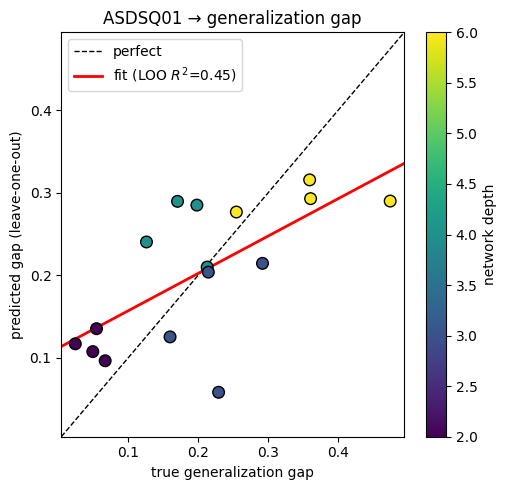

In [7]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score

y = meta["gap"].values
reg = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 20)))
y_hat = cross_val_predict(reg, S, y, cv=LeaveOneOut())
r2 = r2_score(y, y_hat)

fig, ax = plt.subplots(figsize=(5.2, 5))
sc = ax.scatter(y, y_hat, c=meta["depth"], cmap="viridis", s=70, edgecolor="k", zorder=3)
lims = [min(y.min(), y_hat.min()) - 0.02, max(y.max(), y_hat.max()) + 0.02]
ax.plot(lims, lims, "k--", lw=1, label="perfect")
m, b = np.polyfit(y, y_hat, 1)
xs = np.linspace(*lims, 50)
ax.plot(xs, m * xs + b, "r-", lw=2, label=f"fit (LOO $R^2$={r2:.2f})")
ax.set(xlim=lims, ylim=lims, xlabel="true generalization gap",
       ylabel="predicted gap (leave-one-out)",
       title="ASDSQ01 → generalization gap")
fig.colorbar(sc, ax=ax, label="network depth"); ax.legend(); fig.tight_layout()
print(f"leave-one-out R^2 = {r2:.3f}   (paper, full scale: 0.56 on CIFAR-10)")

## 5. Interpretability — reproducing Fig. 4.3  *(inline)*

The paper's clearest qualitative finding: holding depth roughly fixed, networks
with a **higher average of deaths** and a **lower standard deviation of deaths**
generalize better.  Here are the four death-summary panels against the gap,
coloured by depth — the same axes as the paper's Fig. 4.3.

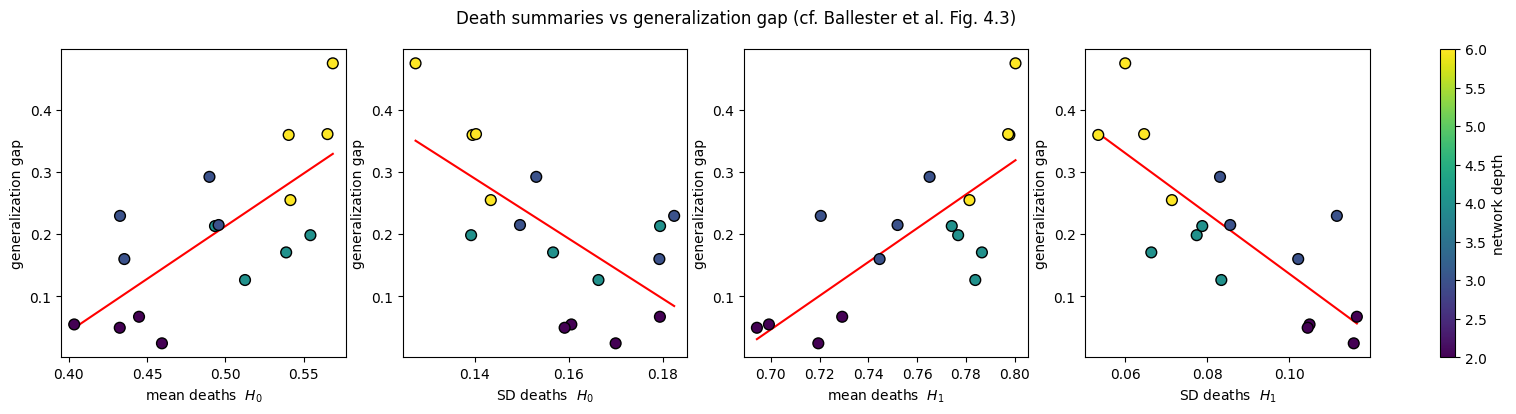

In [8]:
panels = [("H0_mean_death", "mean deaths  $H_0$"), ("H0_std_death", "SD deaths  $H_0$"),
          ("H1_mean_death", "mean deaths  $H_1$"), ("H1_std_death", "SD deaths  $H_1$")]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (col, label) in zip(axes, panels):
    x = asdsq_df[col].values
    sc = ax.scatter(x, y, c=meta["depth"], cmap="viridis", s=60, edgecolor="k", zorder=3)
    if np.ptp(x) > 0:
        m, b = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 50)
        ax.plot(xs, m * xs + b, "r-", lw=1.5)
    ax.set(xlabel=label, ylabel="generalization gap")
fig.colorbar(sc, ax=axes, label="network depth", fraction=0.012)
fig.suptitle("Death summaries vs generalization gap (cf. Ballester et al. Fig. 4.3)")
plt.show()

## Notes & how to scale toward the paper numbers

* **Now built into the toolkit** (no notebook helpers): the correlation functional
  graph, dropping constant neurons, importance-sampling neurons (Eqs. 4.2–4.3), the
  **ASDSQ** persistence summary, and the per-model population fit (`fit_each`).
  `result.statistics` carries ASDSQ for *any* model you push through the preset.
* **Only the regression is inline** — fitting a linear model on the ASDSQ feature
  matrix is the downstream ML task, deliberately left out of the TDA core.
* **Why our `R²` < paper's 0.56:** the paper uses 96 fully-trained nets, 2000 input
  samples, 3000 neurons and a 20×-bootstrap; we use ~16 briefly-trained nets, 256
  inputs, ≤300 neurons and a single importance sample.  Push `EPOCHS`, `N_TRAIN`,
  `N_EVAL`, `MAX_NEURONS` and the grid size up to close the gap.

## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
